In [68]:
# pyright: basic

from dataclasses import dataclass
import inspect
import itertools
from typing import Self, cast
from line_profiler import profile
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import qutip as qt
import qutip.qip
from enum import Enum
from math import factorial, sqrt
from itertools import combinations, product

# set a parameter to see animations in line
from matplotlib import rc
rc('animation', html='jshtml')

# static image plots
%matplotlib inline
# interactive 3D plots
# %matplotlib widget

In [ ]:
ideal_phi_plus = (qt.tensor(qt.basis(2,0), qt.basis(2,0)) + qt.tensor(qt.basis(2,1), qt.basis(2,1))).unit()
ideal_rho = qt.ket2dm(ideal_phi_plus)


first = ideal_rho.ptrace(0)

second = qt.ket2dm((qt.basis(2,0)).unit())

res = qt.tensor(first, second)

res = (res + ideal_rho).unit()

print(qt.fidelity(ideal_rho, res))
print(qt.concurrence(ideal_rho))
print(qt.concurrence(res))



0.790569415042094
0.9999999999999998
0.5000000000000001


/home/riccardo/Desktop/quantum-workspace/venv/lib/python3.12/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


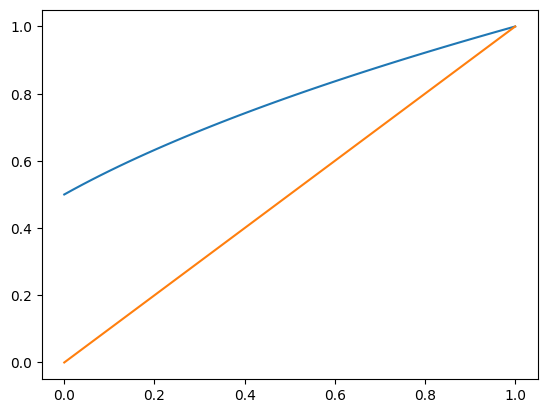

In [87]:
def get_mix(survival_probability: float) -> qt.Qobj:
    ideal_phi_plus = (qt.tensor(qt.basis(2,0), qt.basis(2,0)) + qt.tensor(qt.basis(2,1), qt.basis(2,1))).unit()
    ideal_rho = qt.ket2dm(ideal_phi_plus)

    first = ideal_rho.ptrace(0)

    second = qt.ket2dm((qt.basis(2,0)+qt.basis(2,1)).unit())

    res = qt.tensor(first, second)

    res = ((1-survival_probability) * res + survival_probability*ideal_rho)

    return res



x = np.linspace(0, 1, 50)
fid = []
con = []

for pr in x:
    res = get_mix(pr)
    fid.append(qt.fidelity(ideal_rho, res))
    con.append(qt.concurrence(res))

plt.plot(x, fid, label="fid")
plt.plot(x, con, label="con")
plt.show()

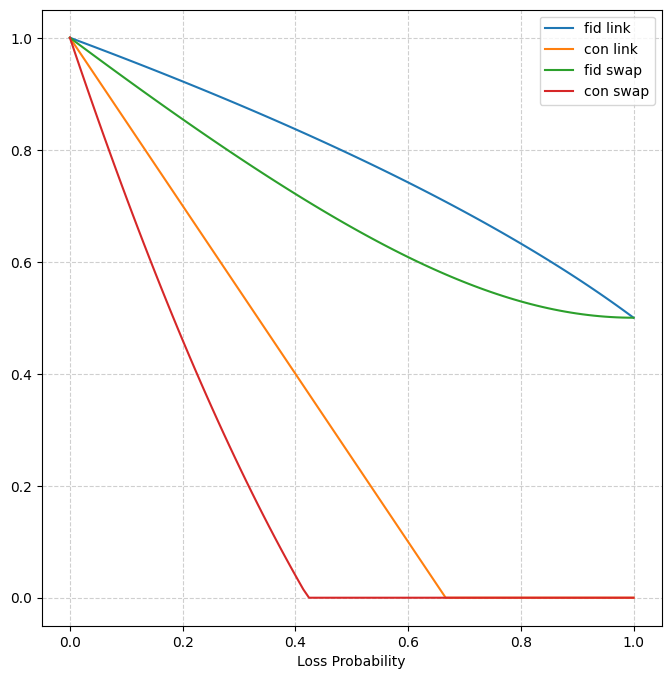

In [135]:
ideal_phi_plus = (qt.tensor(qt.basis(2,0), qt.basis(2,0)) + qt.tensor(qt.basis(2,1), qt.basis(2,1))).unit()
ideal_rho = qt.ket2dm(ideal_phi_plus)

def get_mix(survival_probability: float) -> qt.Qobj:
    ideal_phi_plus = (qt.tensor(qt.basis(2,0), qt.basis(2,0)) + qt.tensor(qt.basis(2,1), qt.basis(2,1))).unit()
    ideal_rho = qt.ket2dm(ideal_phi_plus)

    first = ideal_rho.ptrace(0)

    # second = qt.ket2dm((qt.basis(2,0)))
    second = qt.qeye(2).unit()

    res = qt.tensor(first, second)

    res = ((1-survival_probability) * res + survival_probability*ideal_rho)

    return res



x = np.linspace(0, 1, 100)
fid = []
con = []
fid2 = []
con2 = []

for loss_prob in x:
    mix_res = get_mix(1-loss_prob)

    fid.append(qt.fidelity(ideal_rho, mix_res))
    con.append(qt.concurrence(mix_res))

    link_sx = mix_res
    link_dx = mix_res.permute([1,0])

    two_pairs = qt.tensor(link_sx, link_dx)

    cnot = qt.tensor(qt.qeye(2), qt.gates.cnot(), qt.qeye(2))
    hadamard = qt.tensor(qt.qeye(2), qt.gates.snot(), qt.qeye(2), qt.qeye(2))

    two_pairs = cnot @ two_pairs @ cnot.dag()
    two_pairs = hadamard @ two_pairs @ hadamard.dag()

    bsm_probs = two_pairs.ptrace([1,2]).diag()
    bsm_outcomes = [(0,0), (0,1), (1,0), (1,1)]

    projected_list = []

    for bsm_i in range(4):
        outcome = bsm_outcomes[bsm_i]
        outcome_prob = bsm_probs[bsm_i]
        
        projector_sx = qt.basis(2, outcome[0]).proj()
        projector_dx = qt.basis(2, outcome[1]).proj()

        full_projector = qt.tensor(qt.qeye(2), projector_sx, projector_dx, qt.qeye(2))

        projected = full_projector @ two_pairs @ full_projector.dag()

        edge_uncorrected = projected.ptrace([0, 3])
        
        correction = qt.tensor(qt.qeye(2), qt.qeye(2))

        if outcome == (0,1):
            correction = qt.tensor(qt.qeye(2), qt.sigmax())
        elif outcome == (1,0):
            correction = qt.tensor(qt.qeye(2), qt.sigmaz())
        elif outcome == (1,1):
            correction = qt.tensor(qt.qeye(2), qt.sigmay())

        edge_corrected = correction @ edge_uncorrected @ correction.dag()
        projected_list.append(edge_corrected)

    swap_res = projected_list[0] + projected_list[1] + projected_list[2] + projected_list[3]
    fid2.append(qt.fidelity(ideal_rho, swap_res))
    con2.append(qt.concurrence(swap_res))

plt.figure(figsize=[8, 8])
plt.plot(x, fid, label="fid link")
plt.plot(x, con, label="con link")
plt.plot(x, fid2, label="fid swap")
plt.plot(x, con2, label="con swap")

plt.xlabel('Loss Probability')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()